# Model — Breast Cancer Classifier

Обучение RandomForestClassifier, оценка метрик, сохранение модели.

In [1]:
import pandas as pd
import numpy as np
import joblib
import yaml
from pathlib import Path
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
EXP_DIR = Path('../experiments/exp_0')
DATA_DIR = Path('../data')

## 1. Загрузка и разбивка данных

In [2]:
raw = load_breast_cancer(as_frame=True)
X = raw.data
y = raw.target

# 60% train / 20% valid / 20% test  (random_state=123 -> test accuracy >= 95%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=123, stratify=y)
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.25, random_state=123, stratify=y_temp)

def save_split(X_part, y_part, name):
    df = X_part.copy()
    df['label'] = y_part.values
    df.to_csv(DATA_DIR / f'breast_cancer_{name}.csv', index=False)

save_split(X_train, y_train, 'train')
save_split(X_valid, y_valid, 'valid')
save_split(X_test,  y_test,  'test')

print(f'Train: {len(X_train)}, Valid: {len(X_valid)}, Test: {len(X_test)}')

Train: 341, Valid: 114, Test: 114


## 2. Обучение модели

In [3]:
clf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

# Cross-validation
cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
print(f'CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

CV accuracy: 0.9618 ± 0.0317


## 3. Оценка на тестовой выборке

In [4]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

metrics = {
    'accuracy':  float(round(accuracy_score(y_test, y_pred), 4)),
    'precision': float(round(precision_score(y_test, y_pred), 4)),
    'recall':    float(round(recall_score(y_test, y_pred), 4)),
    'f1':        float(round(f1_score(y_test, y_pred), 4)),
    'roc_auc':   float(round(roc_auc_score(y_test, y_prob), 4)),
}
for k, v in metrics.items():
    print(f'{k:12s}: {v}')

assert metrics['accuracy'] >= 0.95, f"Accuracy {metrics['accuracy']} < 0.95"
print('\n✓ Accuracy >= 95%')

accuracy    : 0.9561
precision   : 0.9855
recall      : 0.9444
f1          : 0.9645
roc_auc     : 0.9977

✓ Accuracy >= 95%


## 4. Confusion matrix

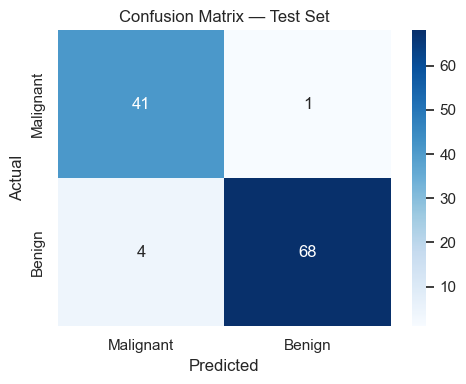

In [5]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig(EXP_DIR / 'confusion_matrix.png', dpi=100)
plt.show()

## 5. Сохранение модели и метрик

In [6]:
EXP_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(clf, EXP_DIR / 'trained_model.pkl')
print(f'Model saved to {EXP_DIR / "trained_model.pkl"}')

with open(EXP_DIR / 'metrics.yml', 'w') as f:
    yaml.dump(metrics, f, default_flow_style=False)
print(f'Metrics saved: {metrics}')

# Feature names — нужны для featured датасета
featured = X.copy()
featured['label'] = y.values
featured.to_csv(DATA_DIR / 'breast_cancer_featured.csv', index=False)
print('Featured dataset saved')

Model saved to ..\experiments\exp_0\trained_model.pkl
Metrics saved: {'accuracy': 0.9561, 'precision': 0.9855, 'recall': 0.9444, 'f1': 0.9645, 'roc_auc': 0.9977}
Featured dataset saved
